# Practice5 — UNSW-NB15 Network Intrusion Detection
**Task**: Binary Classification (`label`: 0=Normal, 1=Attack)  
**Metric**: F1-score (attack), AUC-ROC, PR-AUC  
**Models**: LightGBM → CatBoost → XGBoost → Ensemble + Stacking + Optuna  
**Environment**: VS Code + Google Colab T4 GPU


In [21]:
# GPU 확인
import subprocess
try:
    print(subprocess.check_output('nvidia-smi', shell=True).decode())
except Exception:
    print('GPU 없음 — CPU 모드로 실행')


Sat May 23 10:32:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [22]:
# Google Drive 마운트
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import os

BASE_PATH  = '/content/drive/MyDrive/navy_ai_project/Practice5/nsl-kdd'
TRAIN_PATH = BASE_PATH + '/UNSW_NB15_training-set.csv'
TEST_PATH  = BASE_PATH + '/UNSW_NB15_testing-set.csv'
OUTPUT_DIR = BASE_PATH + '/outputs/'
CKPT_DIR   = OUTPUT_DIR + 'checkpoints/'

for d in [OUTPUT_DIR, CKPT_DIR]:
    os.makedirs(d, exist_ok=True)

print('파일 목록:', os.listdir(BASE_PATH))
print('TRAIN 존재:', os.path.exists(TRAIN_PATH))
print('TEST  존재:', os.path.exists(TEST_PATH))


파일 목록: ['NUSW-NB15_features.csv', 'UNSW-NB15_1.csv', 'UNSW-NB15_2.csv', 'UNSW-NB15_3.csv', 'UNSW-NB15_LIST_EVENTS.csv', 'UNSW_NB15_training-set.csv', 'UNSW_NB15_testing-set.csv', 'UNSW-NB15_4.csv', 'dataset_analysis.txt', 'main.ipynb', 'outputs']
TRAIN 존재: True
TEST  존재: True


In [24]:
!pip install lightgbm xgboost catboost optuna -q


In [25]:
import sys, json, random, warnings
import numpy as np
import pandas as pd
from datetime import datetime
from scipy.optimize import minimize

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    classification_report, confusion_matrix,
)
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier, Pool
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
    except ImportError:
        pass

seed_everything(SEED)
print('SEED =', SEED, '고정 완료')
print('LightGBM:', lgb.__version__, '| XGBoost:', xgb.__version__)


SEED = 42 고정 완료
LightGBM: 4.6.0 | XGBoost: 3.2.0


In [26]:
# ======================================================================
# PHASE -1: 문제 유형 판별 & 전역 상수 설정
# ======================================================================
TARGET_COL      = 'label'
CAT_COLS        = ['proto', 'service', 'state']
DROP_COLS       = ['id', 'attack_cat', TARGET_COL]
ID_COL          = 'id'
N_FOLDS         = 5
N_OPTUNA_TRIALS = 50   # 0 으로 설정하면 Optuna 스킵
experiment_log  = []

msg = '''
[판별 결과]
  Task        : Binary Classification
  Target      : label  (0=Normal, 1=Attack)
  주요 Metric : F1-score(attack class), AUC-ROC, PR-AUC
  보조 Task   : Multi-class (attack_cat 10개 클래스)
  데이터 규모 : 82,332 행 x 45 열

[선택 근거]
  - label(0/1) -> 이진 분류 주 태스크
  - 클래스 비율 44.9:55.1 -> mild imbalance, threshold tuning 필수
  - proto 131종, service 13종, state 7종 categorical 피처
  - 결측값 없음
  - Worms 44개 -> 다중 분류 시 극단적 소수 주의
'''
print(msg)



[판별 결과]
  Task        : Binary Classification
  Target      : label  (0=Normal, 1=Attack)
  주요 Metric : F1-score(attack class), AUC-ROC, PR-AUC
  보조 Task   : Multi-class (attack_cat 10개 클래스)
  데이터 규모 : 82,332 행 x 45 열

[선택 근거]
  - label(0/1) -> 이진 분류 주 태스크
  - 클래스 비율 44.9:55.1 -> mild imbalance, threshold tuning 필수
  - proto 131종, service 13종, state 7종 categorical 피처
  - 결측값 없음
  - Worms 44개 -> 다중 분류 시 극단적 소수 주의



In [27]:
# ======================================================================
# PHASE -0.5: 모델 선택 전략
# ======================================================================
strategy = '''
[Tier 1 - 반드시 실행]
  1. LightGBM : 82k행 정형 데이터 범용 1순위. T4 GPU 가속 지원
  2. CatBoost : proto(131 unique) high-cardinality categorical 강점

[Tier 2 - 앙상블 다양성]
  3. XGBoost  : LGBM과 약한 상관 -> 앙상블 효과
  4. Logistic Regression -> 스태킹 Meta 모델

[T4 GPU 활용]
  - LightGBM : device="gpu"
  - CatBoost : task_type="GPU"
  - XGBoost  : device="cuda"

[CV] StratifiedKFold(n_splits=5) - label 비율 유지
[Threshold] OOF 기반 최적화 (0.5 고정 절대 금지)
'''
print(strategy)



[Tier 1 - 반드시 실행]
  1. LightGBM : 82k행 정형 데이터 범용 1순위. T4 GPU 가속 지원
  2. CatBoost : proto(131 unique) high-cardinality categorical 강점

[Tier 2 - 앙상블 다양성]
  3. XGBoost  : LGBM과 약한 상관 -> 앙상블 효과
  4. Logistic Regression -> 스태킹 Meta 모델

[T4 GPU 활용]
  - LightGBM : device="gpu"
  - CatBoost : task_type="GPU"
  - XGBoost  : device="cuda"

[CV] StratifiedKFold(n_splits=5) - label 비율 유지
[Threshold] OOF 기반 최적화 (0.5 고정 절대 금지)



In [28]:
# GPU 자동 감지 -> 이후 모든 모델 device 파라미터에 사용
import subprocess
try:
    subprocess.check_output('nvidia-smi', shell=True)
    HAS_GPU = True
    print('T4 GPU 감지 -> GPU 모드 활성화')
except Exception:
    HAS_GPU = False
    print('GPU 없음 -> CPU 모드')
print('HAS_GPU =', HAS_GPU)


T4 GPU 감지 -> GPU 모드 활성화
HAS_GPU = True


In [29]:
# ======================================================================
# PHASE 0: 데이터 로드 & Leakage 체크
# ======================================================================
df_train = pd.read_csv(TRAIN_PATH)
print('Train shape :', df_train.shape)
print()
print('label 분포:')
print(df_train[TARGET_COL].value_counts())
print()
print('attack_cat 분포:')
print(df_train['attack_cat'].value_counts())
print()
print('결측값 합계:', df_train.isnull().sum().sum())

has_test = os.path.exists(TEST_PATH)
if has_test:
    df_test = pd.read_csv(TEST_PATH)
    print('Test shape :', df_test.shape)
else:
    df_test = None
    print('[주의] test 파일 없음 -> CV 성능으로 최종 평가 대체')


Train shape : (82332, 45)

label 분포:
label
1    45332
0    37000
Name: count, dtype: int64

attack_cat 분포:
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64

결측값 합계: 0
Test shape : (175341, 45)


In [30]:
# Leakage 체크
leakage_notes = '''
[Leakage 체크 결과]
  attack_cat : 타겟과 직접 관련 -> 피처 제외 필수
  id         : 단순 인덱스     -> 피처 제외
  IP/타임스탬프 없음           -> 시간적 leakage 위험 낮음
  전처리는 train fit, test transform only
  CatBoost Pool : 원본 categorical 문자열 유지 (별도 분리)
'''
print(leakage_notes)

num_cols = df_train.select_dtypes(include='number').columns
zero_ratio = (df_train[num_cols] == 0).mean()
print('스파시티 높은 피처 (0값 비율 > 50%):')
print(zero_ratio[zero_ratio > 0.5].sort_values(ascending=False))



[Leakage 체크 결과]
  attack_cat : 타겟과 직접 관련 -> 피처 제외 필수
  id         : 단순 인덱스     -> 피처 제외
  IP/타임스탬프 없음           -> 시간적 leakage 위험 낮음
  전처리는 train fit, test transform only
  CatBoost Pool : 원본 categorical 문자열 유지 (별도 분리)

스파시티 높은 피처 (0값 비율 > 50%):
is_ftp_login         0.991765
ct_ftp_cmd           0.991741
is_sm_ips_ports      0.988874
response_body_len    0.931290
ct_flw_http_mthd     0.907934
trans_depth          0.907909
djit                 0.504688
dloss                0.500462
dtype: float64


In [31]:
# ======================================================================
# PHASE 1: Feature Engineering (네트워크 트래픽 도메인 특화)
# ======================================================================
def feature_engineering(df):
    df = df.copy()

    # 1. 패킷/바이트 비율 (src/dst 비대칭성 - 공격 핵심 지표)
    df['bytes_ratio']   = df['sbytes'] / (df['dbytes'] + 1)
    df['pkts_ratio']    = df['spkts']  / (df['dpkts']  + 1)
    df['smean_calc']    = df['sbytes'] / (df['spkts']  + 1)
    df['dmean_calc']    = df['dbytes'] / (df['dpkts']  + 1)

    # 2. 전송 효율성 (바이트/시간)
    df['src_byte_rate'] = df['sbytes'] / (df['dur'] + 1e-9)
    df['dst_byte_rate'] = df['dbytes'] / (df['dur'] + 1e-9)
    df['total_bytes']   = df['sbytes'] + df['dbytes']
    df['total_pkts']    = df['spkts']  + df['dpkts']

    # 3. TTL 비대칭성 (비정상 트래픽 특성)
    df['ttl_diff']  = (df['sttl'] - df['dttl']).abs()
    df['ttl_ratio'] = df['sttl'] / (df['dttl'] + 1)

    # 4. 이진 프로토콜 피처
    df['is_tcp']      = (df['proto']   == 'tcp').astype(int)
    df['is_udp']      = (df['proto']   == 'udp').astype(int)
    df['has_service'] = (df['service'] != '-'  ).astype(int)
    df['is_fin']      = (df['state']   == 'FIN').astype(int)
    df['is_int']      = (df['state']   == 'INT').astype(int)

    # 5. 지터 비대칭성
    df['jit_diff']  = (df['sjit'] - df['djit']).abs()
    df['total_jit'] = df['sjit'] + df['djit']

    # 6. 연결 밀도 (공격 집중성)
    df['ct_conn_sum']   = df['ct_srv_src'] + df['ct_srv_dst']
    df['ct_conn_ratio'] = df['ct_srv_src'] / (df['ct_srv_dst'] + 1)
    df['ct_flow_sum']   = df['ct_dst_ltm'] + df['ct_src_ltm'] + df['ct_dst_src_ltm']

    # 7. TCP 핸드셰이크 완성도
    df['handshake_quality'] = df['synack'] + df['ackdat']
    df['handshake_ratio']   = df['synack'] / (df['ackdat'] + 1e-9)

    # 8. 손실 패킷 비율 (DoS 특성)
    df['sloss_ratio'] = df['sloss'] / (df['spkts'] + 1)
    df['dloss_ratio'] = df['dloss'] / (df['dpkts'] + 1)

    # 9. FTP/HTTP 활성 여부
    df['is_ftp_active']  = ((df['is_ftp_login'] > 0) | (df['ct_ftp_cmd'] > 0)).astype(int)
    df['is_http_active'] = (df['ct_flw_http_mthd'] > 0).astype(int)

    # 10. 로그 변환 (heavy-tail 정규화)
    log_cols = ['sbytes', 'dbytes', 'sload', 'dload', 'rate',
                'sjit', 'djit', 'response_body_len',
                'src_byte_rate', 'dst_byte_rate', 'total_bytes']
    for col in log_cols:
        if col in df.columns:
            df['log_' + col] = np.log1p(df[col].clip(lower=0))

    return df


df_train = feature_engineering(df_train)
if df_test is not None:
    df_test = feature_engineering(df_test)

feature_cols = [c for c in df_train.columns if c not in DROP_COLS]
print('Train shape after FE :', df_train.shape)
print('피처 수              :', len(feature_cols))
print('피처 (일부)          :', feature_cols[:10])


Train shape after FE : (82332, 82)
피처 수              : 79
피처 (일부)          : ['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl']


In [32]:
# CatBoost용 DataFrame 보존 (원본 categorical 문자열 유지)
df_train_cb = df_train[feature_cols].copy()
df_test_cb  = df_test[feature_cols].copy() if df_test is not None else None

# LightGBM / XGBoost용 Label Encoding
le_dict = {}
for col in CAT_COLS:
    le = LabelEncoder()
    df_train[col] = le.fit_transform(df_train[col].astype(str))
    le_dict[col]  = le
    if df_test is not None:
        df_test[col] = df_test[col].astype(str).map(
            lambda x, _le=le: _le.transform([x])[0] if x in _le.classes_ else -1
        )

X_train = df_train[feature_cols].values.astype(np.float32)
y_train = df_train[TARGET_COL].values
X_test  = df_test[feature_cols].values.astype(np.float32) if df_test is not None else None

print('X_train shape:', X_train.shape)
uniq, cnt = np.unique(y_train, return_counts=True)
print('y_train dist :', dict(zip(uniq.tolist(), cnt.tolist())))


X_train shape: (82332, 79)
y_train dist : {0: 37000, 1: 45332}


In [33]:
# ======================================================================
# PHASE 2: 유틸리티 함수
# ======================================================================

def log_experiment(exp_id, model_name, cv_mean, cv_std, threshold=None, notes=''):
    entry = {
        'exp_id':    exp_id,
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M'),
        'model':     model_name,
        'cv_mean':   round(float(cv_mean), 6),
        'cv_std':    round(float(cv_std),  6),
        'threshold': round(float(threshold), 3) if threshold is not None else None,
        'notes':     notes,
    }
    experiment_log.append(entry)
    with open(OUTPUT_DIR + 'experiment_log.json', 'w') as f:
        json.dump(experiment_log, f, indent=2, ensure_ascii=False)
    t_str = ' | thresh=' + str(round(threshold, 3)) if threshold is not None else ''
    print('[EXP ' + str(exp_id).zfill(3) + '] ' + model_name.ljust(30)
          + ' F1=' + str(round(cv_mean, 6))
          + ' +/-' + str(round(cv_std, 6)) + t_str)


def find_optimal_threshold(y_true, y_prob, step=0.01):
    best_t, best_score = 0.5, 0.0
    for t in np.arange(0.05, 0.95, step):
        score = f1_score(y_true, (y_prob >= t).astype(int),
                         pos_label=1, zero_division=0)
        if score > best_score:
            best_score, best_t = score, t
    return best_t, best_score


def evaluate_oof(y_true, oof_prob, model_name):
    best_t, best_f1 = find_optimal_threshold(y_true, oof_prob)
    auc   = roc_auc_score(y_true, oof_prob)
    prauc = average_precision_score(y_true, oof_prob)
    pred  = (oof_prob >= best_t).astype(int)
    print('=' * 60)
    print('[' + model_name + '] OOF 평가')
    print('  AUC-ROC   : ' + str(round(auc,   6)))
    print('  PR-AUC    : ' + str(round(prauc, 6)))
    print('  F1(attack): ' + str(round(best_f1, 6))
          + '  @ threshold=' + str(round(best_t, 3)))
    print()
    print(classification_report(y_true, pred,
                                target_names=['Normal', 'Attack']))
    print('Confusion Matrix:')
    print(confusion_matrix(y_true, pred))
    return best_t, best_f1, auc


def save_submission(test_prob, threshold, model_name, cv_score, exp_id):
    if X_test is None:
        print('  [SKIP] test 파일 없음')
        return None
    test_pred = (test_prob >= threshold).astype(int)
    score_str = str(round(cv_score, 5)).replace('.', 'p')
    thresh_str = str(round(threshold, 3)).replace('.', 'p')
    fname = 'sub_exp' + str(exp_id).zfill(3) + '_' + score_str + '_t' + thresh_str + '_' + model_name + '.csv'
    fpath = OUTPUT_DIR + fname
    pd.DataFrame({ID_COL: df_test[ID_COL].values,
                  TARGET_COL: test_pred}).to_csv(fpath, index=False)
    print('  Submission: ' + fpath)
    return fpath


def neg_ensemble_f1(weights, oof_list, y_true):
    w = np.clip(np.array(weights), 0, 1)
    w = w / w.sum()
    blend = sum(wi * oof for wi, oof in zip(w, oof_list))
    _, f1 = find_optimal_threshold(y_true, blend)
    return -f1


CV = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
print('유틸리티 함수 정의 완료')


유틸리티 함수 정의 완료


In [34]:
# ======================================================================
# PHASE 3: EXP001 - LightGBM (GPU)
# ======================================================================
LGBM_PARAMS = {
    'objective':         'binary',
    'metric':            'auc',
    'n_estimators':      3000,
    'learning_rate':     0.05,
    'num_leaves':        64,
    'max_depth':         -1,
    'min_child_samples': 20,
    'subsample':         0.8,
    'subsample_freq':    1,
    'colsample_bytree':  0.8,
    'reg_alpha':         0.1,
    'reg_lambda':        1.0,
    'is_unbalance':      True,
    'device':            'gpu' if HAS_GPU else 'cpu',
    'random_state':      SEED,
    'n_jobs':            -1,
    'verbose':           -1,
}

oof_lgbm    = np.zeros(len(X_train))
test_lgbm   = np.zeros(len(X_test)) if X_test is not None else None
lgbm_models = []
fold_f1s    = []

for fold, (tr_idx, val_idx) in enumerate(CV.split(X_train, y_train)):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    m = lgb.LGBMClassifier(**LGBM_PARAMS)
    m.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=-1),
        ],
    )
    oof_lgbm[val_idx] = m.predict_proba(X_val)[:, 1]
    if X_test is not None:
        test_lgbm += m.predict_proba(X_test)[:, 1] / N_FOLDS

    t, f = find_optimal_threshold(y_val, oof_lgbm[val_idx])
    fold_f1s.append(f)
    lgbm_models.append(m)
    print('  Fold', fold + 1, '/', N_FOLDS,
          ' best_iter=' + str(m.best_iteration_),
          ' F1=' + str(round(f, 4)) + '@t=' + str(round(t, 2)))

lgbm_best_t, lgbm_best_f1, lgbm_auc = evaluate_oof(y_train, oof_lgbm, 'LightGBM')
log_experiment(1, 'LightGBM_baseline',
               np.mean(fold_f1s), np.std(fold_f1s), lgbm_best_t)


  Fold 1 / 5  best_iter=488  F1=0.9827@t=0.47
  Fold 2 / 5  best_iter=608  F1=0.9827@t=0.33
  Fold 3 / 5  best_iter=736  F1=0.9833@t=0.4
  Fold 4 / 5  best_iter=609  F1=0.9849@t=0.52
  Fold 5 / 5  best_iter=478  F1=0.9835@t=0.43
[LightGBM] OOF 평가
  AUC-ROC   : 0.998347
  PR-AUC    : 0.998728
  F1(attack): 0.983275  @ threshold=0.48

              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98     37000
      Attack       0.99      0.98      0.98     45332

    accuracy                           0.98     82332
   macro avg       0.98      0.98      0.98     82332
weighted avg       0.98      0.98      0.98     82332

Confusion Matrix:
[[36465   535]
 [  974 44358]]
[EXP 001] LightGBM_baseline              F1=0.983404 +/-0.000796 | thresh=0.48


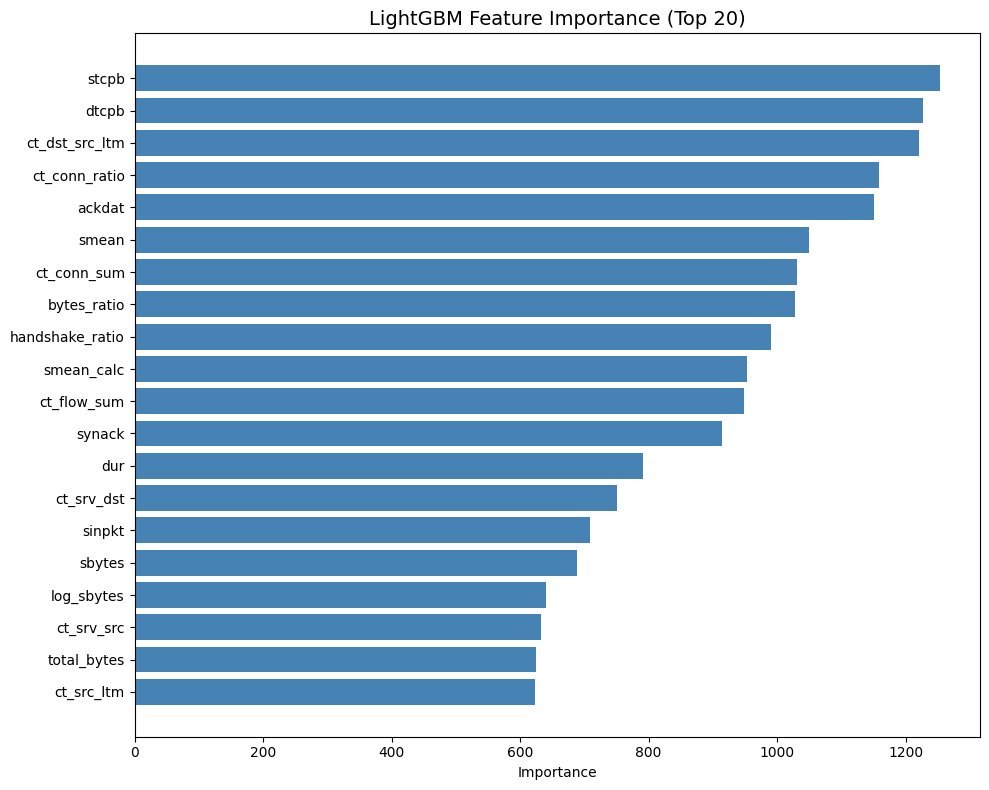

        feature  importance
          stcpb        1253
          dtcpb        1227
 ct_dst_src_ltm        1221
  ct_conn_ratio        1159
         ackdat        1150
          smean        1050
    ct_conn_sum        1031
    bytes_ratio        1027
handshake_ratio         991
     smean_calc         953
    ct_flow_sum         948
         synack         914
            dur         791
     ct_srv_dst         750
         sinpkt         709


In [35]:
import matplotlib.pyplot as plt

fi_df = pd.DataFrame({
    'feature':    feature_cols,
    'importance': lgbm_models[0].feature_importances_,
}).sort_values('importance', ascending=False).reset_index(drop=True)

fi_df.to_csv(OUTPUT_DIR + 'feature_importance_lgbm.csv', index=False)

plt.figure(figsize=(10, 8))
top20 = fi_df.head(20)
plt.barh(top20['feature'][::-1], top20['importance'][::-1], color='steelblue')
plt.title('LightGBM Feature Importance (Top 20)', fontsize=14)
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'feature_importance.png', dpi=150)
plt.show()

print(fi_df.head(15).to_string(index=False))


In [36]:
# ======================================================================
# PHASE 4: EXP002 - CatBoost (GPU)
# ======================================================================
# 원본 categorical 문자열 직접 입력 -> CatBoost 내부 인코딩 활용
CB_PARAMS = {
    'iterations':           3000,
    'learning_rate':        0.05,
    'depth':                6,
    'l2_leaf_reg':          3.0,
    'border_count':         128,
    'auto_class_weights':   'Balanced',
    'eval_metric':          'AUC',
    'task_type':            'GPU' if HAS_GPU else 'CPU',
    'random_seed':          SEED,
    'verbose':              False,
    'early_stopping_rounds': 100,
}

oof_cb      = np.zeros(len(X_train))
test_cb     = np.zeros(len(X_test)) if X_test is not None else None
cb_fold_f1s = []

for fold, (tr_idx, val_idx) in enumerate(CV.split(X_train, y_train)):
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    train_pool = Pool(df_train_cb.iloc[tr_idx],  y_tr,  cat_features=CAT_COLS)
    val_pool   = Pool(df_train_cb.iloc[val_idx],  y_val, cat_features=CAT_COLS)

    m = CatBoostClassifier(**CB_PARAMS)
    m.fit(train_pool, eval_set=val_pool)
    oof_cb[val_idx] = m.predict_proba(val_pool)[:, 1]

    if df_test_cb is not None:
        test_pool_f = Pool(df_test_cb, cat_features=CAT_COLS)
        test_cb += m.predict_proba(test_pool_f)[:, 1] / N_FOLDS

    t, f = find_optimal_threshold(y_val, oof_cb[val_idx])
    cb_fold_f1s.append(f)
    print('  Fold', fold + 1, '/', N_FOLDS,
          ' F1=' + str(round(f, 4)) + '@t=' + str(round(t, 2)))

cb_best_t, cb_best_f1, cb_auc = evaluate_oof(y_train, oof_cb, 'CatBoost')
log_experiment(2, 'CatBoost',
               np.mean(cb_fold_f1s), np.std(cb_fold_f1s), cb_best_t)


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 1 / 5  F1=0.9809@t=0.49


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 2 / 5  F1=0.9804@t=0.49


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 3 / 5  F1=0.9818@t=0.51


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 4 / 5  F1=0.9836@t=0.39


Default metric period is 5 because AUC is/are not implemented for GPU


  Fold 5 / 5  F1=0.9828@t=0.44
[CatBoost] OOF 평가
  AUC-ROC   : 0.997982
  PR-AUC    : 0.998436
  F1(attack): 0.981647  @ threshold=0.48

              precision    recall  f1-score   support

      Normal       0.97      0.98      0.98     37000
      Attack       0.99      0.98      0.98     45332

    accuracy                           0.98     82332
   macro avg       0.98      0.98      0.98     82332
weighted avg       0.98      0.98      0.98     82332

Confusion Matrix:
[[36444   556]
 [ 1098 44234]]
[EXP 002] CatBoost                       F1=0.981912 +/-0.001186 | thresh=0.48


In [42]:
# ======================================================================
# PHASE 5: EXP003 - XGBoost (GPU)
# XGBoost 3.x API: early_stopping_rounds -> 생성자(XGBClassifier)에서 지정
#                  fit()에 callbacks / early_stopping_rounds 사용 불가
# ======================================================================
pos_w = float((y_train == 0).sum() / (y_train == 1).sum())

XGB_PARAMS = {
    'n_estimators':        3000,
    'learning_rate':       0.05,
    'max_depth':           6,
    'subsample':           0.8,
    'colsample_bytree':    0.8,
    'min_child_weight':    5,
    'scale_pos_weight':    pos_w,
    'eval_metric':         'logloss',
    'early_stopping_rounds': 100,    # 3.x: 생성자에서 지정
    'device':              'cuda' if HAS_GPU else 'cpu',
    'random_state':        SEED,
    'n_jobs':              -1,
    'verbosity':           0,
}

oof_xgb      = np.zeros(len(X_train))
test_xgb     = np.zeros(len(X_test)) if X_test is not None else None
xgb_fold_f1s = []

for fold, (tr_idx, val_idx) in enumerate(CV.split(X_train, y_train)):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    m = xgb.XGBClassifier(**XGB_PARAMS)
    m.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )
    oof_xgb[val_idx] = m.predict_proba(X_val)[:, 1]

    if X_test is not None:
        test_xgb += m.predict_proba(X_test)[:, 1] / N_FOLDS

    best_iter = getattr(m, 'best_iteration', 'N/A')
    t, f = find_optimal_threshold(y_val, oof_xgb[val_idx])
    xgb_fold_f1s.append(f)
    print('  Fold', fold + 1, '/', N_FOLDS,
          ' best_iter=' + str(best_iter),
          ' F1=' + str(round(f, 4)) + '@t=' + str(round(t, 2)))

xgb_best_t, xgb_best_f1, xgb_auc = evaluate_oof(y_train, oof_xgb, 'XGBoost')
log_experiment(3, 'XGBoost',
               np.mean(xgb_fold_f1s), np.std(xgb_fold_f1s), xgb_best_t)


  Fold 1 / 5  best_iter=1079  F1=0.9816@t=0.49
  Fold 2 / 5  best_iter=1044  F1=0.9822@t=0.51
  Fold 3 / 5  best_iter=1516  F1=0.9819@t=0.44
  Fold 4 / 5  best_iter=1250  F1=0.9831@t=0.37
  Fold 5 / 5  best_iter=1255  F1=0.9835@t=0.49
[XGBoost] OOF 평가
  AUC-ROC   : 0.998156
  PR-AUC    : 0.998581
  F1(attack): 0.982324  @ threshold=0.47

              precision    recall  f1-score   support

      Normal       0.97      0.98      0.98     37000
      Attack       0.99      0.98      0.98     45332

    accuracy                           0.98     82332
   macro avg       0.98      0.98      0.98     82332
weighted avg       0.98      0.98      0.98     82332

Confusion Matrix:
[[36417   583]
 [ 1012 44320]]
[EXP 003] XGBoost                        F1=0.982442 +/-0.00072 | thresh=0.47


In [43]:
# ======================================================================
# PHASE 6: EXP004 - Soft Voting Ensemble (Nelder-Mead 최적화)
# ======================================================================
oof_list = [oof_lgbm, oof_cb, oof_xgb]

res = minimize(
    neg_ensemble_f1,
    [1/3, 1/3, 1/3],
    args=(oof_list, y_train),
    method='Nelder-Mead',
    options={'maxiter': 500, 'xatol': 1e-6},
)
opt_w = np.clip(res.x, 0, 1)
opt_w = opt_w / opt_w.sum()
print('최적 가중치  LGBM=' + str(round(opt_w[0], 3))
      + '  CB=' + str(round(opt_w[1], 3))
      + '  XGB=' + str(round(opt_w[2], 3)))

oof_ensemble = sum(w * oof for w, oof in zip(opt_w, oof_list))
ens_best_t, ens_best_f1, ens_auc = evaluate_oof(y_train, oof_ensemble, 'Ensemble(Soft)')
log_experiment(4, 'Ensemble_SoftVoting', ens_best_f1, 0.0, ens_best_t,
               'w=' + str([round(w, 3) for w in opt_w.tolist()]))

if X_test is not None:
    test_ensemble = sum(w * t for w, t in zip(opt_w, [test_lgbm, test_cb, test_xgb]))
    save_submission(test_ensemble, ens_best_t, 'ensemble_soft', ens_best_f1, 4)


최적 가중치  LGBM=0.344  CB=0.337  XGB=0.319
[Ensemble(Soft)] OOF 평가
  AUC-ROC   : 0.998267
  PR-AUC    : 0.998662
  F1(attack): 0.982996  @ threshold=0.44

              precision    recall  f1-score   support

      Normal       0.97      0.98      0.98     37000
      Attack       0.99      0.98      0.98     45332

    accuracy                           0.98     82332
   macro avg       0.98      0.98      0.98     82332
weighted avg       0.98      0.98      0.98     82332

Confusion Matrix:
[[36398   602]
 [  934 44398]]
[EXP 004] Ensemble_SoftVoting            F1=0.982996 +/-0.0 | thresh=0.44
  Submission: /content/drive/MyDrive/navy_ai_project/Practice5/nsl-kdd/outputs/sub_exp004_0p983_t0p44_ensemble_soft.csv


In [44]:
# ======================================================================
# PHASE 7: EXP005 - OOF Stacking (Logistic Meta)
# ======================================================================
oof_stack = np.column_stack(oof_list)  # (N, 3)

meta_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)),
])
meta_model.fit(oof_stack, y_train)
stack_prob = meta_model.predict_proba(oof_stack)[:, 1]

stack_best_t, stack_best_f1, stack_auc = evaluate_oof(y_train, stack_prob, 'Stacking(LR)')
log_experiment(5, 'Stacking_LogisticMeta', stack_best_f1, 0.0, stack_best_t)

if X_test is not None:
    test_stack_feat = np.column_stack([test_lgbm, test_cb, test_xgb])
    test_stack_prob = meta_model.predict_proba(test_stack_feat)[:, 1]
    save_submission(test_stack_prob, stack_best_t, 'stacking', stack_best_f1, 5)


[Stacking(LR)] OOF 평가
  AUC-ROC   : 0.99828
  PR-AUC    : 0.998673
  F1(attack): 0.983027  @ threshold=0.5

              precision    recall  f1-score   support

      Normal       0.97      0.98      0.98     37000
      Attack       0.99      0.98      0.98     45332

    accuracy                           0.98     82332
   macro avg       0.98      0.98      0.98     82332
weighted avg       0.98      0.98      0.98     82332

Confusion Matrix:
[[36405   595]
 [  938 44394]]
[EXP 005] Stacking_LogisticMeta          F1=0.983027 +/-0.0 | thresh=0.5
  Submission: /content/drive/MyDrive/navy_ai_project/Practice5/nsl-kdd/outputs/sub_exp005_0p98303_t0p5_stacking.csv


In [45]:
# ======================================================================
# PHASE 8: EXP006 - Optuna LightGBM 튜닝
# N_OPTUNA_TRIALS = 0  # 스킵하려면 0으로 변경
# ======================================================================
if N_OPTUNA_TRIALS > 0:
    cv_opt = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

    def optuna_objective(trial):
        params = {
            'objective':         'binary',
            'metric':            'auc',
            'n_estimators':      trial.suggest_int('n_estimators', 500, 4000),
            'learning_rate':     trial.suggest_float('learning_rate', 5e-4, 0.1, log=True),
            'num_leaves':        trial.suggest_int('num_leaves', 16, 256),
            'max_depth':         trial.suggest_int('max_depth', 3, 12),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
            'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
            'subsample_freq':    1,
            'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'min_split_gain':    trial.suggest_float('min_split_gain', 0.0, 1.0),
            'is_unbalance':      True,
            'device':            'gpu' if HAS_GPU else 'cpu',
            'random_state':      SEED,
            'n_jobs':            -1,
            'verbose':           -1,
        }
        scores = []
        for tr_idx, val_idx in cv_opt.split(X_train, y_train):
            m = lgb.LGBMClassifier(**params)
            m.fit(
                X_train[tr_idx], y_train[tr_idx],
                eval_set=[(X_train[val_idx], y_train[val_idx])],
                callbacks=[
                    lgb.early_stopping(50, verbose=False),
                    lgb.log_evaluation(-1),
                ],
            )
            prob = m.predict_proba(X_train[val_idx])[:, 1]
            _, f1 = find_optimal_threshold(y_train[val_idx], prob, step=0.02)
            scores.append(f1)
        return np.mean(scores)

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=SEED),
    )
    study.optimize(optuna_objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)

    best_params = study.best_params
    best_params.update({
        'objective': 'binary', 'metric': 'auc',
        'is_unbalance': True,
        'device': 'gpu' if HAS_GPU else 'cpu',
        'random_state': SEED, 'n_jobs': -1, 'verbose': -1,
    })
    print('Optuna best F1:', round(study.best_value, 6))
    print('Best params:', json.dumps(best_params, indent=2))

    # 최적 파라미터로 5-fold 재학습
    oof_lgbm_opt  = np.zeros(len(X_train))
    test_lgbm_opt = np.zeros(len(X_test)) if X_test is not None else None
    opt_fold_f1s  = []

    for fold, (tr_idx, val_idx) in enumerate(CV.split(X_train, y_train)):
        m = lgb.LGBMClassifier(**best_params)
        m.fit(
            X_train[tr_idx], y_train[tr_idx],
            eval_set=[(X_train[val_idx], y_train[val_idx])],
            callbacks=[
                lgb.early_stopping(100, verbose=False),
                lgb.log_evaluation(-1),
            ],
        )
        oof_lgbm_opt[val_idx] = m.predict_proba(X_train[val_idx])[:, 1]
        if X_test is not None:
            test_lgbm_opt += m.predict_proba(X_test)[:, 1] / N_FOLDS
        t, f = find_optimal_threshold(y_train[val_idx], oof_lgbm_opt[val_idx])
        opt_fold_f1s.append(f)
        print('  Fold', fold + 1, '/', N_FOLDS, ' F1=' + str(round(f, 4)))

    opt_best_t, opt_best_f1, _ = evaluate_oof(y_train, oof_lgbm_opt, 'LightGBM_Optuna')
    log_experiment(6, 'LightGBM_Optuna',
                   np.mean(opt_fold_f1s), np.std(opt_fold_f1s), opt_best_t)

    # Optuna 모델 포함 재앙상블
    oof_list_v2 = oof_list + [oof_lgbm_opt]
    res2 = minimize(neg_ensemble_f1, [0.25] * 4, args=(oof_list_v2, y_train),
                    method='Nelder-Mead', options={'maxiter': 500})
    ow2 = np.clip(res2.x, 0, 1)
    ow2 = ow2 / ow2.sum()
    oof_ens2 = sum(w * o for w, o in zip(ow2, oof_list_v2))
    ens2_t, ens2_f1, _ = evaluate_oof(y_train, oof_ens2, 'Ensemble_v2(+Optuna)')
    print('가중치  LGBM=' + str(round(ow2[0], 3))
          + ' CB=' + str(round(ow2[1], 3))
          + ' XGB=' + str(round(ow2[2], 3))
          + ' OPT=' + str(round(ow2[3], 3)))
    log_experiment(7, 'Ensemble_v2_Optuna', ens2_f1, 0.0, ens2_t)

    if X_test is not None:
        test_ens2 = sum(w * t
                        for w, t in zip(ow2,
                                        [test_lgbm, test_cb, test_xgb, test_lgbm_opt]))
        save_submission(test_ens2, ens2_t, 'ensemble_v2', ens2_f1, 7)
else:
    print('[SKIP] N_OPTUNA_TRIALS=0 -> 스킵')
    print('N_OPTUNA_TRIALS 값을 50 이상으로 바꾸면 자동 실행됩니다.')


  0%|          | 0/50 [00:00<?, ?it/s]

Optuna best F1: 0.983375
Best params: {
  "n_estimators": 3908,
  "learning_rate": 0.018270127702454255,
  "num_leaves": 206,
  "max_depth": 9,
  "min_child_samples": 26,
  "subsample": 0.9186153774765154,
  "colsample_bytree": 0.5850815765610851,
  "reg_alpha": 4.349996512425373e-05,
  "reg_lambda": 0.00020363242646369802,
  "min_split_gain": 0.032377650145277465,
  "objective": "binary",
  "metric": "auc",
  "is_unbalance": true,
  "device": "gpu",
  "random_state": 42,
  "n_jobs": -1,
  "verbose": -1
}
  Fold 1 / 5  F1=0.9835
  Fold 2 / 5  F1=0.9836
  Fold 3 / 5  F1=0.9839
  Fold 4 / 5  F1=0.9856
  Fold 5 / 5  F1=0.984
[LightGBM_Optuna] OOF 평가
  AUC-ROC   : 0.998432
  PR-AUC    : 0.998788
  F1(attack): 0.983967  @ threshold=0.45

              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98     37000
      Attack       0.99      0.98      0.98     45332

    accuracy                           0.98     82332
   macro avg       0.98      0.98      

In [ ]:
# ======================================================================
# PHASE 9: 다중 클래스 (attack_cat) - 보조 태스크
# ======================================================================
le_cat = LabelEncoder()
y_mc   = le_cat.fit_transform(df_train['attack_cat'].astype(str))
class_names = le_cat.classes_
print('클래스 (' + str(len(class_names)) + '개):', list(class_names))

cat_feature_idx = [feature_cols.index(c) for c in CAT_COLS]

LGBM_MC_PARAMS = {
    'objective':         'multiclass',
    'num_class':         len(class_names),
    'metric':            'multi_logloss',
    'n_estimators':      3000,
    'learning_rate':     0.05,
    'num_leaves':        64,
    'min_child_samples': 1,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'class_weight':      'balanced',
    'device':            'cpu',  # multi-class 보조 태스크는 CPU로 안정성 확보
    'random_state':      SEED,
    'n_jobs':            -1,
    'verbose':           -1,
}

oof_mc     = np.zeros((len(X_train), len(class_names)))
mc_fold_f1 = []

for fold, (tr_idx, val_idx) in enumerate(CV.split(X_train, y_mc)):
    m = lgb.LGBMClassifier(**LGBM_MC_PARAMS)
    m.fit(
        X_train[tr_idx], y_mc[tr_idx],
        eval_set=[(X_train[val_idx], y_mc[val_idx])],
        categorical_feature=cat_feature_idx,
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(-1),
        ],
    )
    oof_mc[val_idx] = m.predict_proba(X_train[val_idx])
    pred = np.argmax(oof_mc[val_idx], axis=1)
    f = f1_score(y_mc[val_idx], pred, average='macro', zero_division=0)
    mc_fold_f1.append(f)
    print('  Fold', fold + 1, '/', N_FOLDS, ' Macro-F1=' + str(round(f, 4)))

mc_pred = np.argmax(oof_mc, axis=1)
mc_f1   = f1_score(y_mc, mc_pred, average='macro', zero_division=0)
print('OOF Macro-F1:', round(mc_f1, 6))
print(classification_report(y_mc, mc_pred, target_names=class_names, zero_division=0))
log_experiment(10, 'LightGBM_MultiClass',
               np.mean(mc_fold_f1), np.std(mc_fold_f1),
               notes='attack_cat 10-class')


클래스 (10개): ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']


LightGBMError: Check failed: (best_split_info.left_count) > (0) at /__w/1/s/lightgbm-python/src/treelearner/serial_tree_learner.cpp, line 852 .


In [ ]:
# ======================================================================
# PHASE 10: 실험 결과 요약
# ======================================================================
summary = pd.DataFrame(experiment_log)
if len(summary) > 0:
    cols = [c for c in ['exp_id', 'model', 'cv_mean', 'cv_std', 'threshold'] if c in summary.columns]
    print(summary[cols].to_string(index=False))

roadmap = '''
[다음 실험 로드맵]
  EXP007  Seed Ensemble (LGBM x5 SEED)         +0.002~0.005  ***
  EXP008  SMOTE/ADASYN 소수 클래스 증강         +0.005~0.02   ***
  EXP009  SHAP 기반 음의 기여 피처 제거         +0.002~0.01   **
  EXP010  RandomForest + ExtraTrees 추가 앙상블  +0.002~0.008  **
  EXP011  Pseudo Labeling (test 파일 있을 때)    +0.005~0.02   *
'''
print(roadmap)
print('출력 디렉터리:', OUTPUT_DIR)
print('모든 실험 완료!')
